In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import accuracy_score, confusion_matrix
import seaborn as sns

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)

cuda


In [2]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

train_dataset = torchvision.datasets.MNIST(root='./data', train=True, download=True, transform=transform)
test_dataset = torchvision.datasets.MNIST(root='./data', train=False, download=True, transform=transform)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

print(f"Train size: {len(train_dataset)}, Test size: {len(test_dataset)}")

100%|██████████| 9.91M/9.91M [00:00<00:00, 20.5MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 496kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.73MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 17.4MB/s]

Train size: 60000, Test size: 10000


In [3]:
class MLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.flatten = nn.Flatten()
        self.fc1 = nn.Linear(28*28, 512)
        self.fc2 = nn.Linear(512, 256)
        self.fc3 = nn.Linear(256, 10)
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(0.2)

    def forward(self, x):
        x = self.flatten(x)
        x = self.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.relu(self.fc2(x))
        x = self.dropout(x)
        x = self.fc3(x)
        return x

mlp_model = MLP().to(device)

In [4]:
class CNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 32, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.pool = nn.MaxPool2d(2, 2)
        self.fc1 = nn.Linear(64*7*7, 128)
        self.fc2 = nn.Linear(128, 10)
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(0.25)

    def forward(self, x):
        x = self.relu(self.conv1(x))
        x = self.pool(x)
        x = self.relu(self.conv2(x))
        x = self.pool(x)
        x = x.view(-1, 64*7*7)
        x = self.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)
        return x

cnn_model = CNN().to(device)

In [5]:
def train_model(model, epochs=10):
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001)

    for epoch in range(epochs):
        model.train()
        running_loss = 0.0
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()

        print(f"Epoch {epoch+1}/{epochs}, Loss: {running_loss/len(train_loader):.4f}")
    return model

print("Training MLP...")
mlp_model = train_model(mlp_model, epochs=5)  # fewer epochs for speed

print("\nTraining CNN...")
cnn_model = train_model(cnn_model, epochs=8)

Training MLP...
Epoch 1/5, Loss: 0.2371
Epoch 2/5, Loss: 0.1110
Epoch 3/5, Loss: 0.0873
Epoch 4/5, Loss: 0.0725
Epoch 5/5, Loss: 0.0626

Training CNN...
Epoch 1/8, Loss: 0.1600
Epoch 2/8, Loss: 0.0539
Epoch 3/8, Loss: 0.0414
Epoch 4/8, Loss: 0.0307
Epoch 5/8, Loss: 0.0266
Epoch 6/8, Loss: 0.0215
Epoch 7/8, Loss: 0.0189
Epoch 8/8, Loss: 0.0182


In [6]:
def evaluate(model):
    model.eval()
    preds, true_labels = [], []
    with torch.no_grad():
        for images, labels in test_loader:
            images = images.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs, 1)
            preds.extend(predicted.cpu().numpy())
            true_labels.extend(labels.numpy())

    acc = accuracy_score(true_labels, preds)
    print(f"Test Accuracy: {acc*100:.2f}%")
    return preds, true_labels

print("MLP Results:")
mlp_preds, labels = evaluate(mlp_model)

print("\nCNN Results:")
cnn_preds, _ = evaluate(cnn_model)

MLP Results:
Test Accuracy: 97.96%

CNN Results:
Test Accuracy: 99.24%


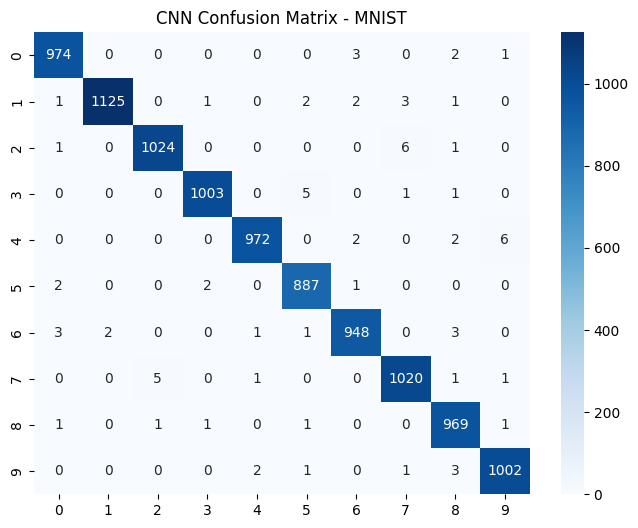

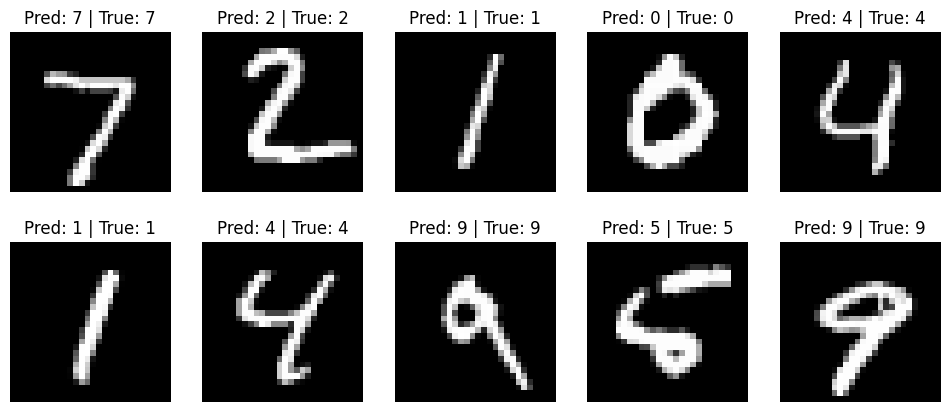

In [7]:
# Confusion Matrix for CNN (best model)
cm = confusion_matrix(labels, cnn_preds)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('CNN Confusion Matrix - MNIST')
plt.show()

# Sample predictions
dataiter = iter(test_loader)
images, labels = next(dataiter)
images = images[:10].to(device)
outputs = cnn_model(images)
_, preds = torch.max(outputs, 1)

fig, axes = plt.subplots(2,5, figsize=(12,5))
for i, ax in enumerate(axes.flat):
    ax.imshow(images[i].cpu().squeeze(), cmap='gray')
    ax.set_title(f"Pred: {preds[i]} | True: {labels[i]}")
    ax.axis('off')
plt.show()